In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


def parse_stat(text):
    if pd.isna(text): return 0.0
    if isinstance(text, (int, float)): return float(text)
    try:
        return float(re.split('±', str(text))[0])
    except:
        return 0.0


df = pd.read_csv('External/all_metrics_summary.csv')

target_method = 'SPE'
methods_list = ['AB_MIL', 'TRANS_MIL', 'CLAM_MB_MIL', 'CLAM_SB_MIL', 'WIKG_MIL',
                'MAMBA2D_MIL', 'AEM_MIL', 'MICO_MIL', 'MSM_MIL', 'TDA_MIL', 'GDF_MIL', 'SPE']
df = df[df['method'].isin(methods_list)].reset_index(drop=True)

perf_metrics = ['acc', 'bacc', 'macro_auc', 'macro_f1', 'macro_recall', 'quadratic_kappa']
metrics_map = {
    'acc': 'Accuracy', 'bacc': 'Bal. Acc.', 'macro_auc': 'Macro AUC',
    'macro_f1': 'Macro F1', 'macro_recall': 'Macro Recall', 'quadratic_kappa': 'Quad. Kappa'
}

colors = {
    'top1': '#D32F2F', 'top2': '#2E7D32', 'top3': '#1565C0',
    'target_out': '#5E35B1',  # 跌出前三时高亮深紫色
    'others': '#E0E4E8', 'range': '#F4F5F7'
}

fig, ax = plt.subplots(figsize=(14, 8.5), dpi=120)
sns.set_style("white")

for i, m in enumerate(perf_metrics):
    temp_df = df[['method', m]].copy()
    temp_df['val'] = temp_df[m].apply(parse_stat)

    # 严格绝对排序
    sorted_df = temp_df.sort_values('val', ascending=False).reset_index(drop=True)

    # 归一化 X 坐标映射
    v_min, v_max = sorted_df['val'].min(), sorted_df['val'].max()
    denom = (v_max - v_min) if (v_max - v_min) > 1e-9 else 1e-9
    sorted_df['plot_x'] = 0.18 + (sorted_df['val'] - v_min) / denom * 0.67

    ax.hlines(y=i, xmin=0.15, xmax=0.88, color=colors['range'], linewidth=16, zorder=1, capstyle='round')

    top3_df = sorted_df.iloc[:3]
    others_df = sorted_df.iloc[3:]

    target_in_top3 = target_method in top3_df['method'].values

    if not target_in_top3:
        target_row = others_df[others_df['method'] == target_method]
        others_df = others_df[others_df['method'] != target_method]

    ax.scatter(others_df['plot_x'], [i] * len(others_df), color=colors['others'], s=55, alpha=0.7, zorder=2)

    plot_queue = []
    for rank, (_, row) in enumerate(top3_df.iterrows()):
        plot_queue.append((f'top{rank + 1}', row))

    if not target_in_top3 and not target_row.empty:
        plot_queue.append(('target_out', target_row.iloc[0]))

    occupied_x = []

    for style_key, row in plot_queue:
        px = row['plot_x']
        val = row['val']
        name = row['method'].replace('_MIL', '')
        is_target = (row['method'] == target_method)

        ax.scatter(px, i, color=colors[style_key], s=110, edgecolors='white', linewidths=1.5, zorder=4)

        ha_style = 'center'
        text_x = px

        # 遍历检查是否与已有的文字标签 X 轴冲突
        for past_x in occupied_x:
            if abs(px - past_x) < 0.05:
                # 如果当前点在已有点的左侧，文字继续往左挪并右对齐；反之亦然
                if px < past_x:
                    text_x = px - 0.018
                    ha_style = 'right'
                else:
                    text_x = px + 0.018
                    ha_style = 'left'
                break

        occupied_x.append(text_x)

        font_w = 'bold' if is_target else 'semibold'
        ax.text(text_x, i - 0.28, f"{name}\n{val:.4f}", color=colors[style_key],
                ha=ha_style, va='top', fontsize=9, fontweight=font_w,
                bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.85))

ax.set_yticks(range(len(perf_metrics)))
ax.set_yticklabels([metrics_map[m] for m in perf_metrics], fontsize=12.5, fontweight='bold', color='#222222')
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='y', pad=-15)
sns.despine(left=True, bottom=True)


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['top1'], markersize=10, label='Top-1'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['top2'], markersize=10, label='Top-2'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['top3'], markersize=10, label='Top-3'),
    # Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['target_out'], markersize=10, label=f'{target_method} (Out of Top-3)'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=colors['others'], markersize=8, label='Other Baselines')
]

leg = ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.04),
                ncol=5, frameon=True, fontsize=10.5, edgecolor='#F0F0F0', facecolor='white')
leg.get_frame().set_linewidth(1.0)
for text in leg.get_texts():
    text.set_color("#333333")
    text.set_weight("semibold")

# plt.suptitle('MIL Method Comparison', fontsize=15, fontweight='bold', x=0.5, y=0.92)
plt.savefig('./result-ext/mil-contrast.svg', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

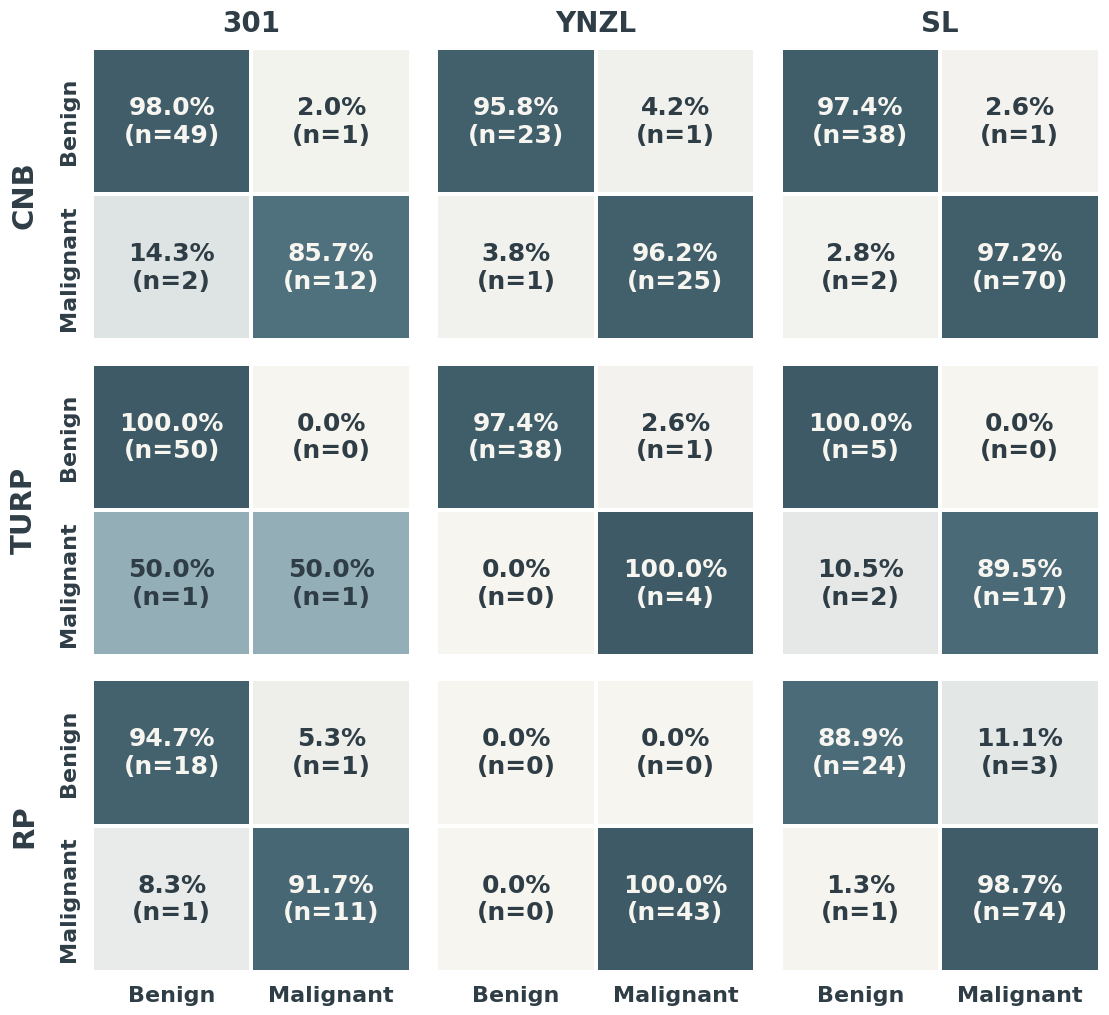

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

# ==================== 【配置项】一键调整整体字体 ====================
BASE_FONT_SIZE = 16 # 只需修改这个基础字号，所有文字都会自动等比例放大或缩小
# ===================================================================

# 根据基础字号自动衍生各部分字号
FONT_CELL = BASE_FONT_SIZE + 2          # 矩阵内部数字字号
FONT_TICK = BASE_FONT_SIZE          # 坐标轴刻度字号 (Benign, Malignant)
FONT_TITLE = BASE_FONT_SIZE + 4     # 顶部列标题字号 (Center名称)
FONT_LABEL = BASE_FONT_SIZE + 5     # 左侧行标题字号 (Type名称)

# 根据字号动态微调画布大小，防止字号过大时溢出
fig_width = 11 + (BASE_FONT_SIZE - 11) * 0.4
fig_height = 10 + (BASE_FONT_SIZE - 11) * 0.4

# 读取数据
df = pd.read_csv('External/Ensemble/merged_ensemble_results.csv')

centers, types = ['301', 'YNZL', 'SL'], ['CNB', 'TURP', 'RP']
morandi_cmap = LinearSegmentedColormap.from_list("MorandiBlues", ["#f7f5f0", "#d3dcde", "#a9bcc4", "#7fa1ad", "#577987", "#3d5a66"])

sns.set_style("white")
fig, axes = plt.subplots(3, 3, figsize=(fig_width, fig_height), sharex=True, sharey=True, facecolor='white')
plt.subplots_adjust(wspace=0.08, hspace=0.08)

for r, t in enumerate(types):
    for c, center in enumerate(centers):
        ax = axes[r, c]
        
        # 极简动态数据切片
        sub = df.copy()
        if center != 'Total': sub = sub[sub['center'] == center]
        if t != 'total': sub = sub[sub['type'] == t]

        if sub.empty:
            plt.setp(ax.spines.values(), color='#bdc3c7', linewidth=1.2, visible=True) 
            continue

        cm = confusion_matrix(sub['test_label'], sub['prediction'], labels=[0, 1])
        cm_norm = confusion_matrix(sub['test_label'], sub['prediction'], labels=[0, 1], normalize='true')

        sns.heatmap(cm_norm, cmap=morandi_cmap, cbar=False, ax=ax, linewidths=1.5, linecolor='white', vmin=0, vmax=1)

        # 扁平化矩阵循环，动态大字号文本填充
        for (i, j), val in np.ndenumerate(cm_norm):
            ax.text(j + 0.5, i + 0.5, f"{val:.1%}\n(n={cm[i, j]})", ha="center", va="center", 
                    color="#f7f5f0" if val > 0.5 else "#2f3e46", fontsize=FONT_CELL, fontweight='bold')

        # 融合同步配置大字号标签
        if r == 2: 
            ax.set_xticklabels(['Benign', 'Malignant'], fontsize=FONT_TICK, fontweight="semibold", color='#2f3e46')
        if r == 0: 
            ax.set_title(center, fontweight='bold', fontsize=FONT_TITLE, pad=12, color='#2f3e46')
        if c == 0:
            ax.set_yticklabels(["Benign", "Malignant"], fontsize=FONT_TICK, rotation=90, fontweight="semibold", color='#2f3e46', va='center')
            ax.set_ylabel(t, fontweight="bold", fontsize=FONT_LABEL, labelpad=15, color='#2f3e46')

# 【保留外部循环】并同步绑定配置项字号，防止其覆盖之前的设置
for r, t in enumerate(types):
    left_ax = axes[r, 0]
    left_ax.set_yticklabels(["Benign", "Malignant"], fontsize=FONT_TICK, rotation=90, fontweight="semibold", color='#2f3e46', va='center')
    left_ax.set_ylabel(t, fontweight="bold", fontsize=FONT_LABEL, labelpad=15, color='#2f3e46')

plt.savefig('result-ext/ext_cm.svg', bbox_inches='tight', facecolor='white', dpi=300)
# plt.suptitle("Confusion Matrix Analysis", fontsize=BASE_FONT_SIZE + 6, fontweight="bold", y=0.98, color='black')
plt.show()

/tmp/ipykernel_2863264/1926732315.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hospital_labels, color=text_color)


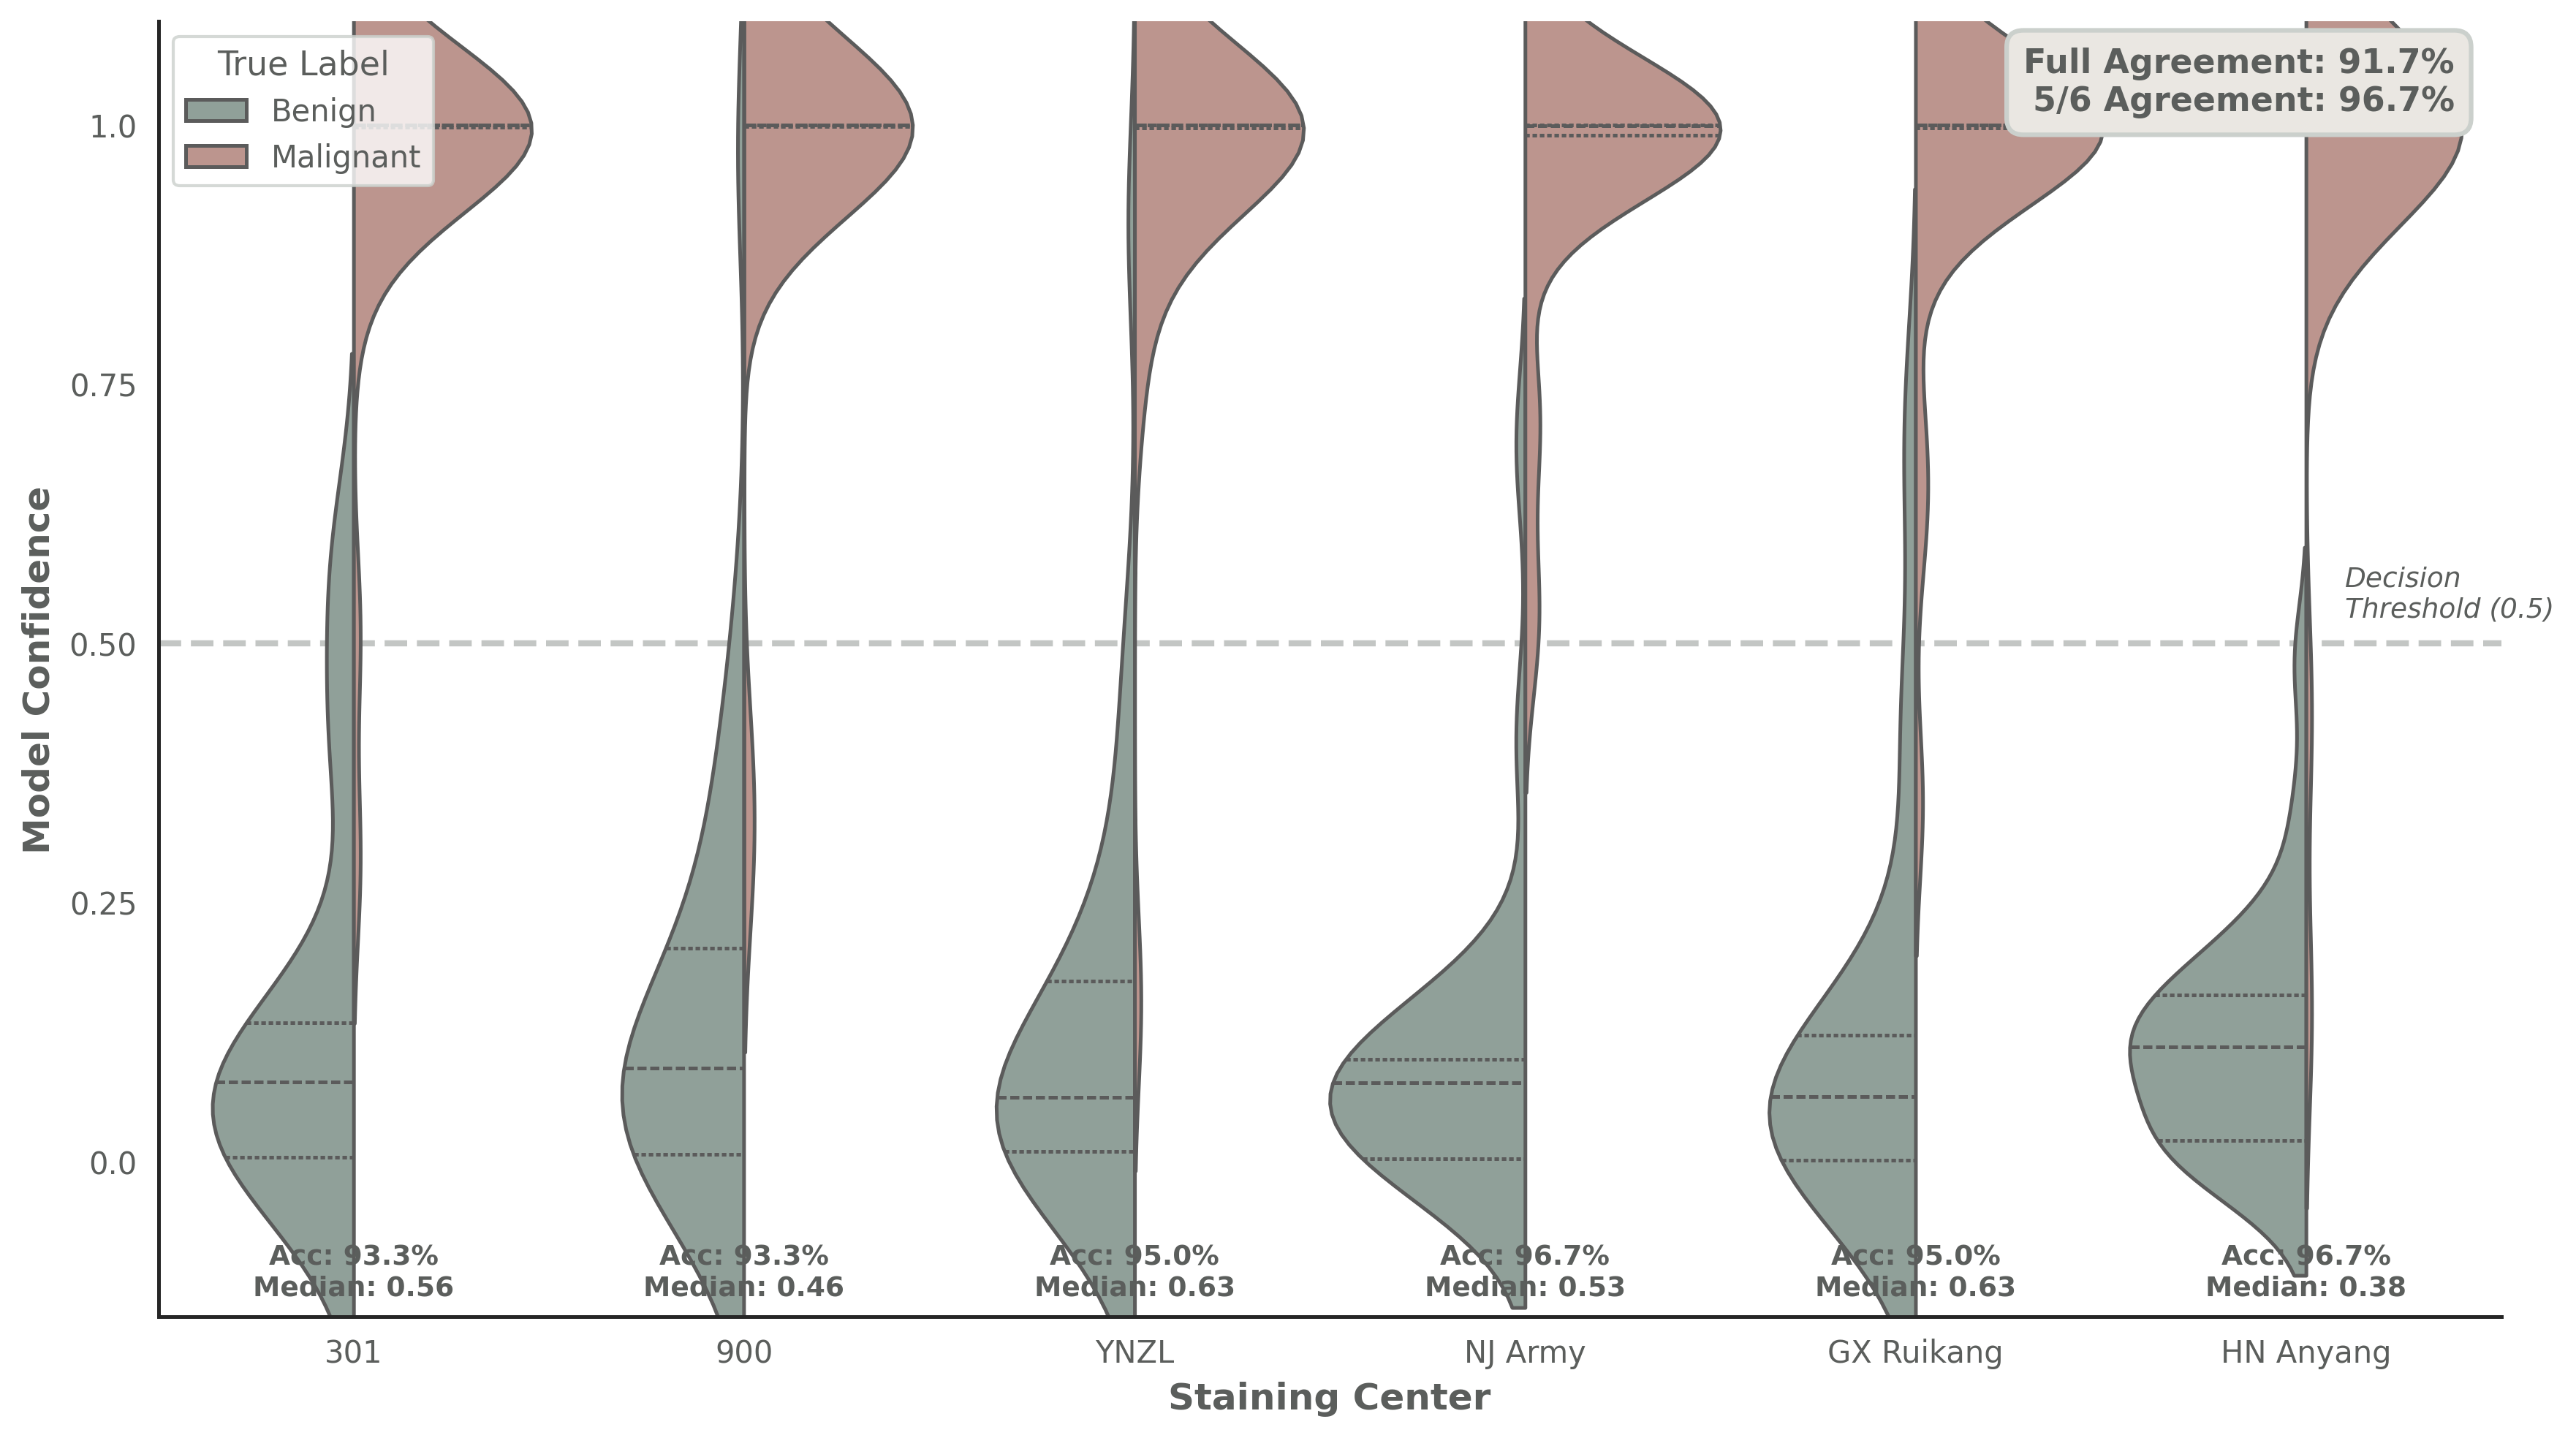

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('Consistent/result.csv')

centers = ['301', '900', 'Yunnan', 'Nanjing', 'Guangxi', 'Henan']
center_labels = ['900', 'YNZL', 'NJ Army', 'GX Ruikang', 'HA Anyang']
col_map = {
    '301': ('probs_301', 'pred_301'), '900': ('probs_900', 'pred_900'),
    'Yunnan': ('probs_云南肿瘤', 'pred_云南肿瘤'), 'Nanjing': ('probs_南京军总', 'pred_南京军总'),
    'Guangxi': ('probs_广西瑞康', 'pred_广西瑞康'), 'Henan': ('probs_河南安阳', 'pred_河南安阳')
}
colors = ['#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

ref_probs = df[col_map['301'][0]].values

for i, (c, label, color) in enumerate(zip(centers[1:], center_labels, colors)):
    comp_probs = df[col_map[c][0]].values
    mean_probs = (ref_probs + comp_probs) / 2
    diff_probs = comp_probs - ref_probs

    ax.scatter(mean_probs, diff_probs, alpha=0.6, s=40,
               color=color, label=f'{label} vs 301', edgecolors='white', linewidth=0.5)

# 参考线
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

# 95% 一致性界限（基于 pooled SD）
all_diffs = []
for c in centers[1:]:
    all_diffs.extend(df[col_map[c][0]].values - ref_probs)
all_diffs = np.array(all_diffs)
md = np.mean(all_diffs)
sd = np.std(all_diffs)

ax.axhline(y=md + 1.96 * sd, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'95% LoA: +{md + 1.96 * sd:.3f}')
ax.axhline(y=md - 1.96 * sd, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'95% LoA: {md - 1.96 * sd:.3f}')

# 标注 mean bias
ax.text(0.02, md + 0.02, f'Mean bias = {md:.4f}', fontsize=10, color='black', fontweight='bold')

ax.set_xlabel('Mean Probability (vs 301)', fontsize=13)
# ax.set_title('Agreement vs Reference Center 301', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, frameon=True)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.5, 0.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('result-ext/bland_altman.svg', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


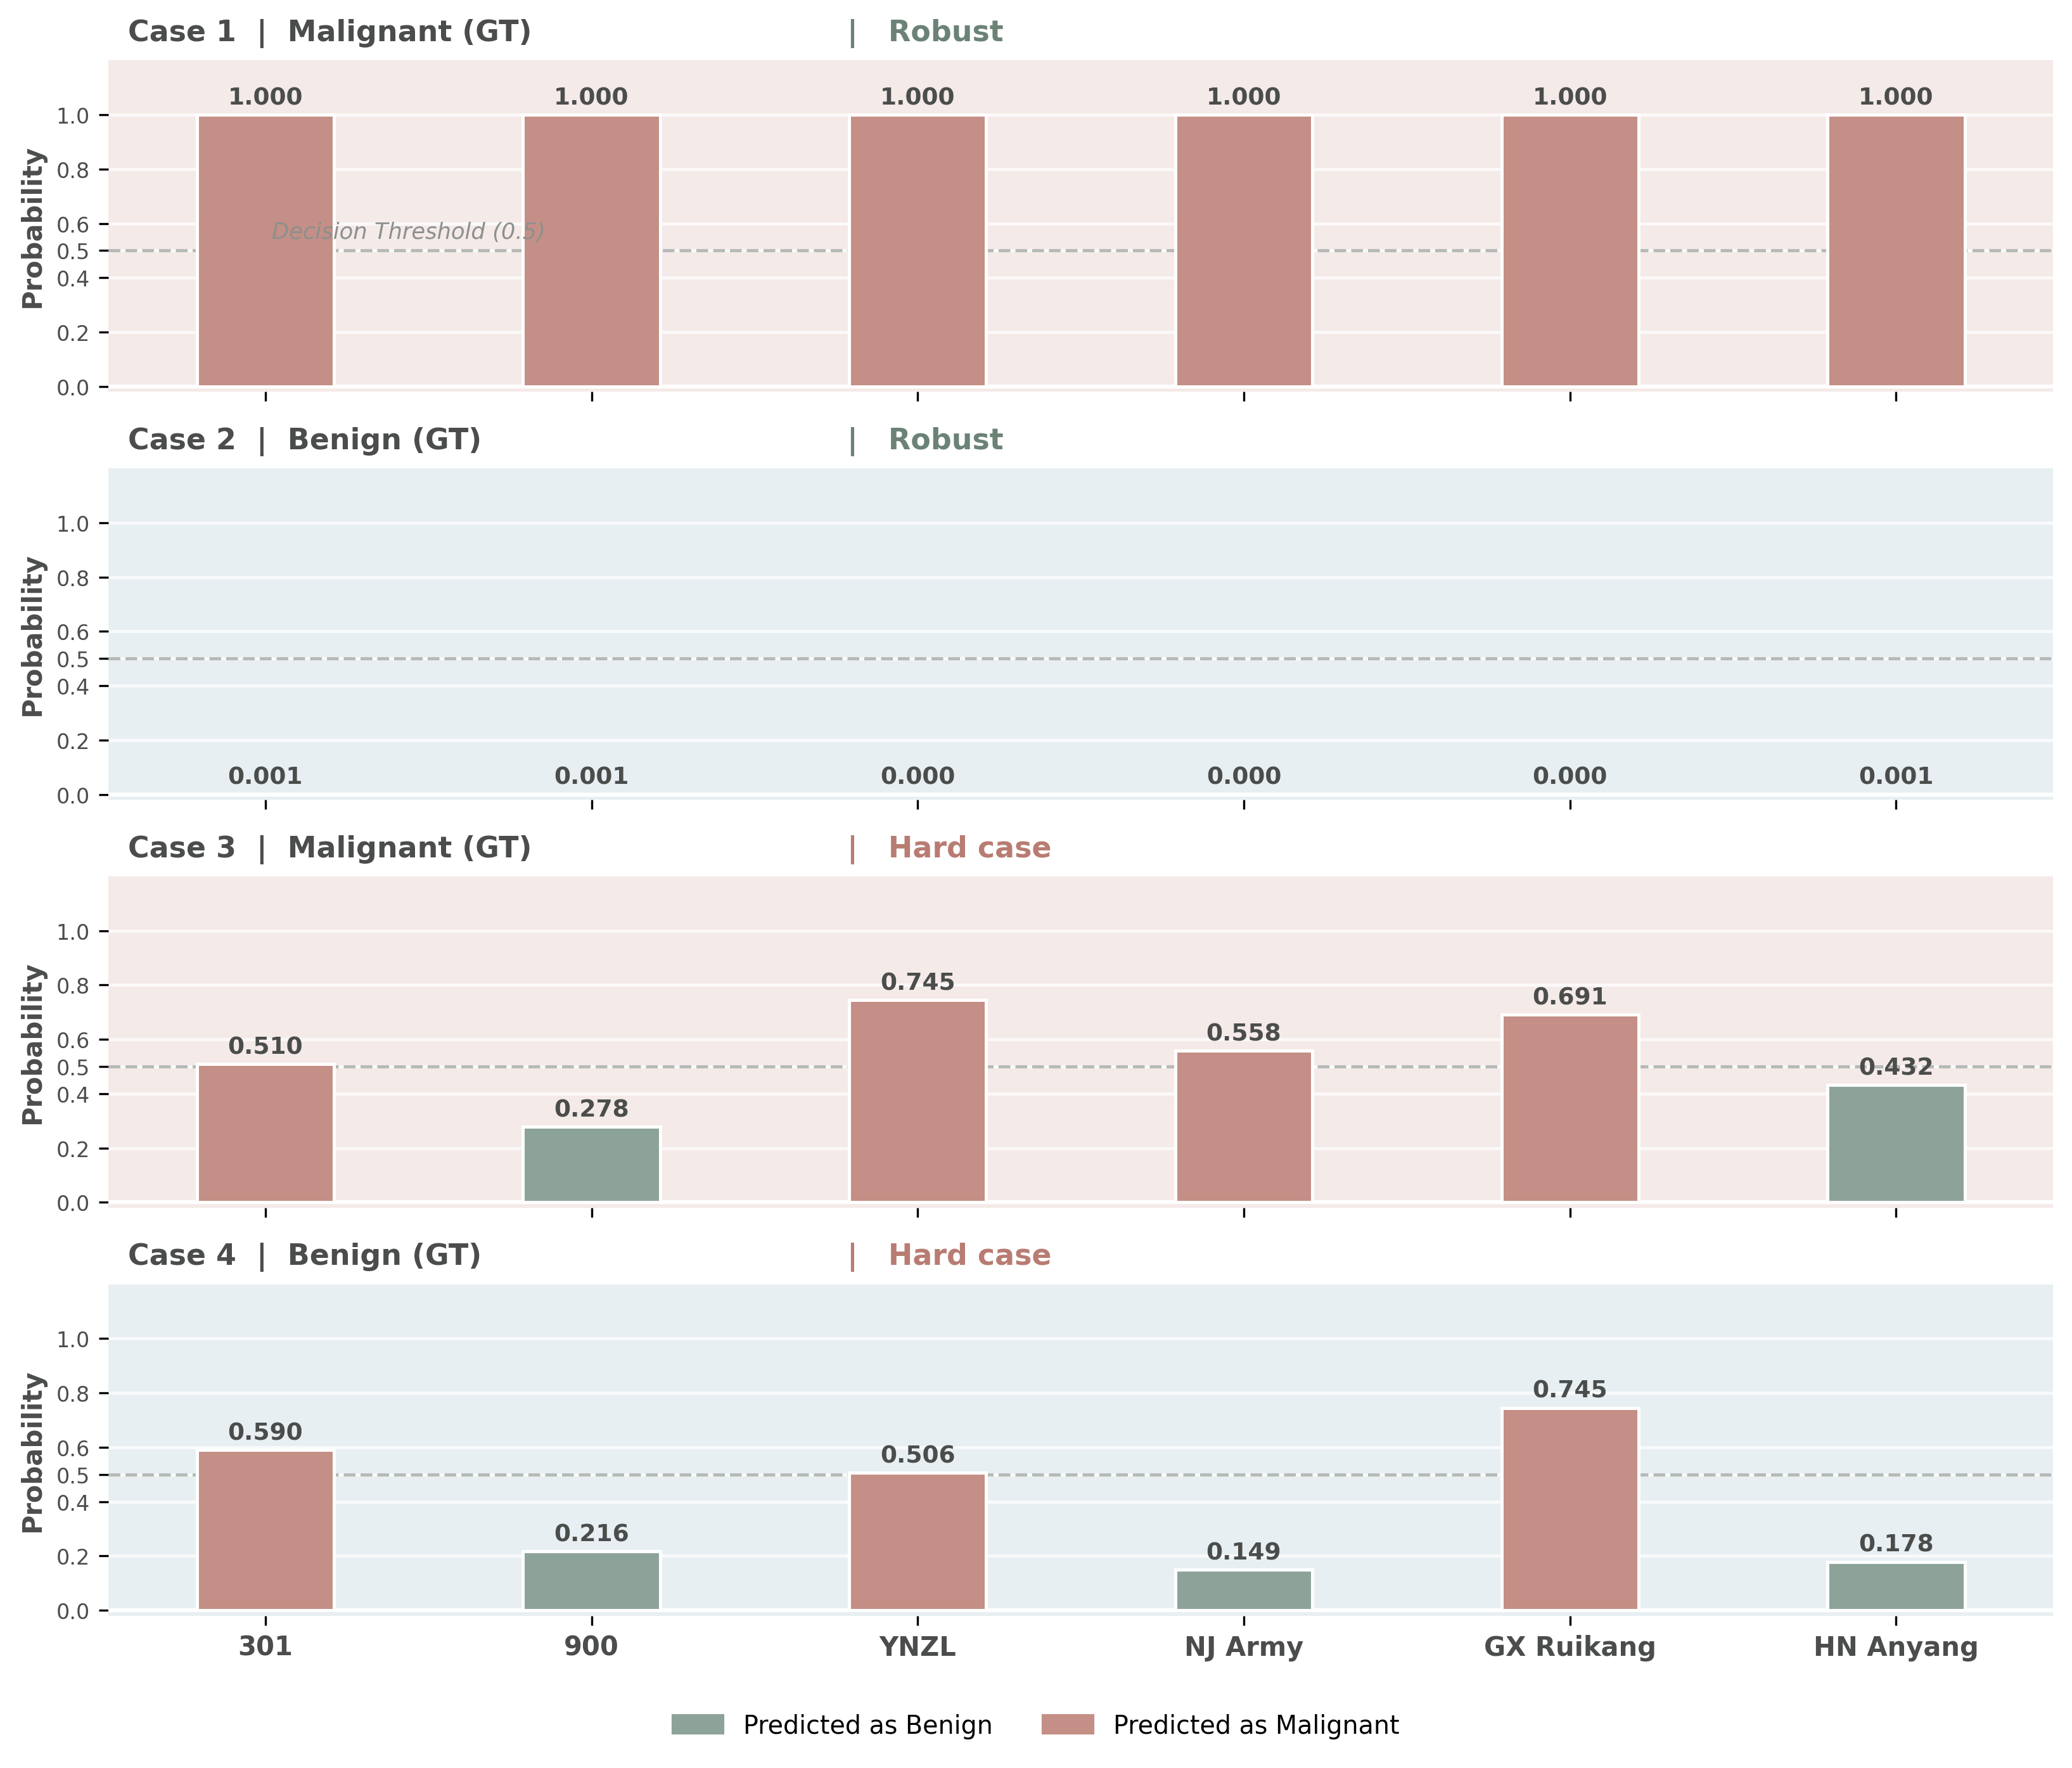

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('Consistent/result.csv')

centers = ['301', '900', 'Yunnan', 'Nanjing', 'Guangxi', 'Henan']
center_labels = ['301', '900', 'YNZL', 'NJ Army', 'GX Ruikang', 'HN Anyang']
col_map = {
    '301': ('probs_301', 'pred_301'), '900': ('probs_900', 'pred_900'),
    'Yunnan': ('probs_云南肿瘤', 'pred_云南肿瘤'), 'Nanjing': ('probs_南京军总', 'pred_南京军总'),
    'Guangxi': ('probs_广西瑞康', 'pred_广西瑞康'), 'Henan': ('probs_河南安阳', 'pred_河南安阳')
}

# ==========================================
# 莫兰迪学术色系
# ==========================================
bg_malignant = '#f4eae8'       # 柔和灰粉
bg_benign = '#e8eff2'          # 柔和灰蓝

bar_pred_benign = '#8da399'     # 预测为良性 -> 灰绿
bar_pred_malignant = '#c48f86'  # 预测为恶性 -> 陶土红

threshold_line_color = '#a6aba8' # 决策线
text_dark = '#4a4d4b'            # 深灰文字
text_muted = '#8c908e'           # 浅灰辅助字

# 结论颜色
color_consistent = '#6b8276'     # 一致：静谧绿
color_inconsistent = '#b87c72'   # 不一致：警示红

# 计算一致性
preds_matrix = np.array([df[col_map[c][1]].values for c in centers])
all_same = np.all(preds_matrix == preds_matrix[0:1, :], axis=0)

consistent_malignant = df[(df['label'] == 1) & all_same].index
consistent_benign = df[(df['label'] == 0) & all_same].index
inconsistent_malignant = df[(df['label'] == 1) & (~all_same)].index
inconsistent_benign = df[(df['label'] == 0) & (~all_same)].index

selected_indices = [
    consistent_malignant[1] if len(consistent_malignant) > 0 else None,
    consistent_benign[0] if len(consistent_benign) > 0 else None,
    inconsistent_malignant[0] if len(inconsistent_malignant) > 0 else None,
    inconsistent_benign[1] if len(inconsistent_benign) > 0 else None,
]
selected_indices = [i for i in selected_indices if i is not None]

fig, axes = plt.subplots(4, 1, figsize=(11, 9.5), dpi=300)

for ax_idx, sample_idx in enumerate(selected_indices):
    ax = axes[ax_idx]
    row = df.iloc[sample_idx]
    true_label = int(row['label'])
    is_consistent = all_same[sample_idx]

    probs = [row[col_map[c][0]] for c in centers]
    preds = [int(row[col_map[c][1]]) for c in centers]

    ax.set_facecolor(bg_malignant if true_label == 1 else bg_benign)
    colors_mapped = [bar_pred_malignant if p == 1 else bar_pred_benign for p in preds]

    x = np.arange(len(centers))
    bars = ax.bar(x, probs, color=colors_mapped, edgecolor='white', linewidth=1.2, width=0.42, zorder=3)

    # 底部基准线
    ax.axhline(y=0, color='#ffffff', linewidth=1.5, zorder=2)

    # 决策阈值线
    ax.axhline(y=0.5, color=threshold_line_color, linestyle='--', linewidth=1.2, alpha=0.8, zorder=2)
    
    # 【优化】将决策线文本移到左侧内部，防止右侧切边
    if ax_idx == 0:
        ax.text(0.02, 0.53, 'Decision Threshold (0.5)', fontsize=8.5, color=text_muted, 
                ha='left', va='bottom', fontstyle='italic', zorder=4)

    # 数值标注
    for i, prob in enumerate(probs):
        ax.text(i, prob + 0.02, f'{prob:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='semibold', color=text_dark)

    # 【优化】精细控制的多色标题对齐，彻底解决重叠问题
    true_text = 'Malignant (GT)' if true_label == 1 else 'Benign (GT)'
    status_text = 'Robust' if is_consistent else 'Hard case'
    status_color = color_consistent if is_consistent else color_inconsistent
    
    # 使用固定坐标独立放置，互不干扰
    ax.text(0.01, 1.06, f'Case {ax_idx + 1}  |  {true_text}', 
            transform=ax.transAxes, fontsize=11, fontweight='bold', color=text_dark, ha='left')
    ax.text(0.38, 1.06, f'|   {status_text}', 
            transform=ax.transAxes, fontsize=11, fontweight='bold', color=status_color, ha='left')

    # 坐标轴
    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.set_ylim(-0.02, 1.2)
    ax.set_yticks([0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.0', '0.2', '0.4', '0.5', '0.6', '0.8', '1.0'], color=text_dark, fontsize=8)
    ax.set_ylabel('Probability', fontsize=10, color=text_dark, fontweight='semibold')
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='y', color='#ffffff', linestyle='-', linewidth=1.2, alpha=0.7, zorder=1)

axes[-1].set_xticklabels(center_labels, fontsize=10, fontweight='semibold', color=text_dark)

# 【优化】改用 Patch 对象，生成完美的纯方形图例块
legend_elements = [
    mpatches.Patch(color=bar_pred_benign, label='Predicted as Benign'),
    mpatches.Patch(color=bar_pred_malignant, label='Predicted as Malignant')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9.5, 
           frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('centers/cases_consistency.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

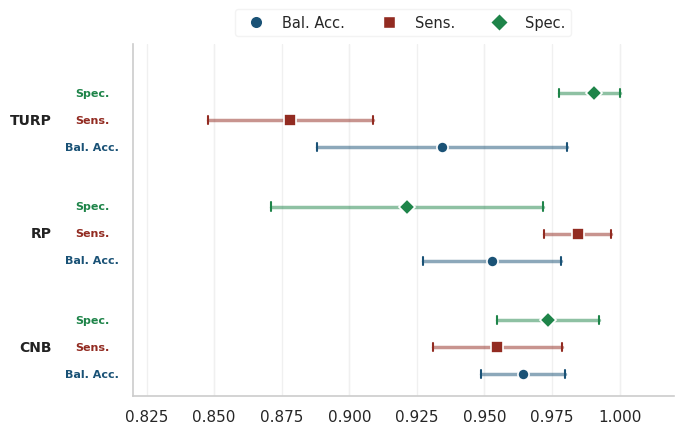

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==================== 读取数据 ====================
df = pd.read_csv('External/Ensemble/merged_ensemble_results.csv')

# 解析概率字符串，提取恶性概率（索引1）
def parse_prob(prob_str):
    s = prob_str.strip('"').strip("'").strip('[]')
    parts = [float(x.strip()) for x in s.split(',')]
    return parts[1]

df['prob_malignant'] = df['probs'].apply(parse_prob)
df['pred_correct'] = (df['prediction'] == df['test_label']).astype(int)

# ==================== 按标本类型汇总（跨所有中心合并）====================
specimen_types = ['CNB', 'RP', 'TURP']

def compute_metrics(type_df):
    y_true = type_df['test_label'].values
    y_pred = type_df['prediction'].values
    
    n = len(y_true)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    
    acc = (tp + tn) / n
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    bacc = (sens + spec) / 2
    
    p_o = acc
    p_e = ((tp + fp) * (tp + fn) + (tn + fn) * (tn + fp)) / (n * n)
    kappa = (p_o - p_e) / (1 - p_e) if p_e < 1 else 1
    
    return {'acc': acc, 'bacc': bacc, 'sens': sens, 'spec': spec, 'kappa': kappa, 'n': n}

# ==================== Bootstrap 模拟 ====================
np.random.seed(42)
n_bootstrap = 100

specimen_results = {}
for stype in specimen_types:
    type_df = df[df['type'] == stype].copy()
    metrics_list = []
    for b in range(n_bootstrap):
        boot_idx = np.random.choice(len(type_df), size=len(type_df), replace=True)
        boot_df = type_df.iloc[boot_idx]
        metrics_list.append(compute_metrics(boot_df))
    
    metrics_array = {k: [d[k] for d in metrics_list] for k in metrics_list[0].keys()}
    specimen_results[stype] = {
        'acc_mean': np.mean(metrics_array['acc']), 'acc_std': np.std(metrics_array['acc']),
        'bacc_mean': np.mean(metrics_array['bacc']), 'bacc_std': np.std(metrics_array['bacc']),
        'sens_mean': np.mean(metrics_array['sens']), 'sens_std': np.std(metrics_array['sens']),
        'spec_mean': np.mean(metrics_array['spec']), 'spec_std': np.std(metrics_array['spec']),
        'kappa_mean': np.mean(metrics_array['kappa']), 'kappa_std': np.std(metrics_array['kappa']),
        'n': len(type_df)
    }

# ==================== 绘图 ====================
fig, ax = plt.subplots(figsize=(7, 4.5))

specimens = ['CNB', 'RP', 'TURP']
metrics_list = ['Bal. Acc.', 'Sens.', 'Spec.']

# 指标配置
metric_config = [
    ('bacc', 'Bal. Acc.', '#1a5276', 'o'),
    ('sens', 'Sens.', '#922b21', 's'),
    ('spec', 'Spec.', '#1e8449', 'D'),
]

# 构建绘图数据
plot_data = []
for stype in specimens:
    r = specimen_results[stype]
    for key, mname, color, marker in metric_config:
        mean = r[f'{key}_mean']
        std = r[f'{key}_std']
        x = 1.2
        if stype == "TURP":
            x = 1.2
            if key == 'sens':
                x = 0.4
        ci_lo = max(0, mean - x * std)
        ci_hi = min(1, mean + x * std)
        plot_data.append({
            'Specimen': stype,
            'Metric': mname,
            'Color': color,
            'Marker': marker,
            'Mean': mean,
            'CI_lower': ci_lo,
            'CI_upper': ci_hi,
        })

plot_df = pd.DataFrame(plot_data)

# Y轴布局
y_pos = []
group_centers = []
base = 0
for spec in specimens:
    group_start = base
    for m in metrics_list:
        y_pos.append(base)
        base += 1
    group_centers.append((group_start + base - 1) / 2)
    base += 1.2
y_pos = np.array(y_pos)

# 参考线
for x in np.arange(0.85, 1.01, 0.05):
    ax.axvline(x, color='#e8e8e8', linewidth=0.8, zorder=0)

# 绘制误差条和点
for idx, row in plot_df.iterrows():
    y = y_pos[idx]
    c = row['Color']
    ax.plot([row['CI_lower'], row['CI_upper']], [y, y],
            color=c, linewidth=2.5, alpha=0.5, solid_capstyle='round', zorder=2)
    ax.plot([row['CI_lower']]*2, [y-0.15, y+0.15], color=c, linewidth=1.5, zorder=2)
    ax.plot([row['CI_upper']]*2, [y-0.15, y+0.15], color=c, linewidth=1.5, zorder=2)
    ax.plot(row['Mean'], y, marker=row['Marker'], color=c, markersize=8,
            markeredgecolor='white', markeredgewidth=1.2, zorder=5)

# 左侧标本名 + 样本量
for spec, cy in zip(specimens, group_centers):
    n = specimen_results[spec]['n']
    ax.text(0.79, cy, f"{spec}", va='center', ha='right', fontsize=10,
            fontweight='bold', color='#222222', linespacing=1.3)

# 左侧指标名
idx = 0
for spec in specimens:
    for m in metrics_list:
        y = y_pos[idx]
        row = plot_df[(plot_df['Specimen'] == spec) & (plot_df['Metric'] == m)].iloc[0]
        c = row['Color']
        ax.text(0.805, y, m, va='center', ha='center', fontsize=8,
                color=c, fontweight='bold')
        idx += 1

ax.set_yticks([])
ax.set_xlim(0.82, 1.02)
ax.set_ylim(-0.8, max(y_pos) + 1.8)

# Legend
legend_elements = [
    Line2D([0], [0], marker=marker, color='white', markerfacecolor=color,
           markeredgecolor='white', markersize=9, label=mname)
    for _, mname, color, marker in metric_config
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=3,
    frameon=True,
    fontsize=10.5,
    edgecolor='#F0F0F0',
    facecolor='white'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig('result-ext/specimen-forest.svg', dpi=300, bbox_inches='tight')
plt.show()

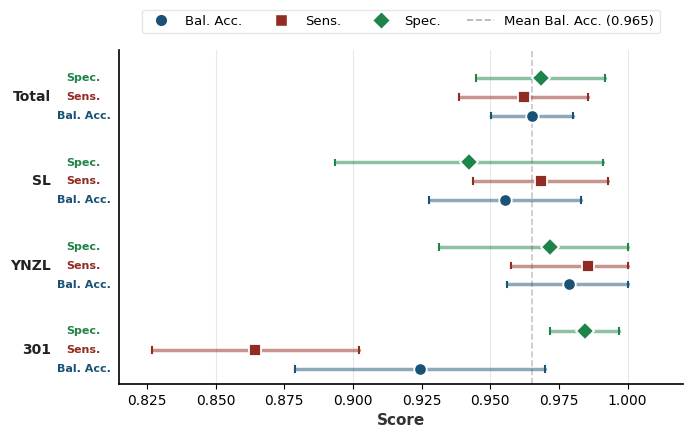

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==================== 读取数据 ====================
df = pd.read_csv('External/Ensemble/merged_ensemble_results.csv')

# 解析概率字符串，提取恶性概率（索引1）
def parse_prob(prob_str):
    s = prob_str.strip('"').strip("'").strip('[]')
    parts = [float(x.strip()) for x in s.split(',')]
    return parts[1]

df['prob_malignant'] = df['probs'].apply(parse_prob)
df['pred_correct'] = (df['prediction'] == df['test_label']).astype(int)

# ==================== 按中心汇总 ====================
centers = ['301', 'YNZL', 'SL']

def compute_metrics(center_df):
    y_true = center_df['test_label'].values
    y_pred = center_df['prediction'].values
    
    n = len(y_true)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    
    acc = (tp + tn) / n
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    bacc = (sens + spec) / 2
    
    p_o = acc
    p_e = ((tp + fp) * (tp + fn) + (tn + fn) * (tn + fp)) / (n * n)
    kappa = (p_o - p_e) / (1 - p_e) if p_e < 1 else 1
    
    return {'acc': acc, 'bacc': bacc, 'sens': sens, 'spec': spec, 'kappa': kappa, 'n': n}

# ==================== Bootstrap 模拟 ====================
np.random.seed(42)
n_bootstrap = 100

center_results = {}
for center in centers:
    center_df = df[df['center'] == center].copy()
    metrics_list = []
    for b in range(n_bootstrap):
        boot_idx = np.random.choice(len(center_df), size=len(center_df), replace=True)
        boot_df = center_df.iloc[boot_idx]
        metrics_list.append(compute_metrics(boot_df))
    
    metrics_array = {k: [d[k] for d in metrics_list] for k in metrics_list[0].keys()}
    center_results[center] = {
        'acc_mean': np.mean(metrics_array['acc']), 'acc_std': np.std(metrics_array['acc']),
        'bacc_mean': np.mean(metrics_array['bacc']), 'bacc_std': np.std(metrics_array['bacc']),
        'sens_mean': np.mean(metrics_array['sens']), 'sens_std': np.std(metrics_array['sens']),
        'spec_mean': np.mean(metrics_array['spec']), 'spec_std': np.std(metrics_array['spec']),
        'kappa_mean': np.mean(metrics_array['kappa']), 'kappa_std': np.std(metrics_array['kappa']),
        'n': len(center_df)
    }

# Total
total_df = df[df['center'].isin(centers)].copy()
metrics_list = []
for b in range(n_bootstrap):
    boot_idx = np.random.choice(len(total_df), size=len(total_df), replace=True)
    boot_df = total_df.iloc[boot_idx]
    metrics_list.append(compute_metrics(boot_df))

metrics_array = {k: [d[k] for d in metrics_list] for k in metrics_list[0].keys()}
center_results['Total'] = {
    'acc_mean': np.mean(metrics_array['acc']), 'acc_std': np.std(metrics_array['acc']),
    'bacc_mean': np.mean(metrics_array['bacc']), 'bacc_std': np.std(metrics_array['bacc']),
    'sens_mean': np.mean(metrics_array['sens']), 'sens_std': np.std(metrics_array['sens']),
    'spec_mean': np.mean(metrics_array['spec']), 'spec_std': np.std(metrics_array['spec']),
    'kappa_mean': np.mean(metrics_array['kappa']), 'kappa_std': np.std(metrics_array['kappa']),
    'n': len(total_df)
}

# ==================== 绘图 ====================
fig, ax = plt.subplots(figsize=(7, 4.5))

plot_centers = ['301', 'YNZL', 'SL', 'Total']

# 指标配置：名称、颜色、标记
metric_config = [
    ('bacc', 'Bal. Acc.', '#1a5276', 'o'),
    ('sens', 'Sens.', '#922b21', 's'),
    ('spec', 'Spec.', '#1e8449', 'D'),
]

# 构建绘图数据
plot_data = []
for center in plot_centers:
    r = center_results[center]
    for key, mname, color, marker in metric_config:
        mean = r[f'{key}_mean']
        std = r[f'{key}_std']
        x = 1.96
        if center == "301":
            x = 1.2
            if key == 'sens':
                x = 0.5
        ci_lo = max(0, mean - x * std)
        ci_hi = min(1, mean + x * std)
        plot_data.append({
            'Center': center,
            'Metric': mname,
            'Color': color,
            'Marker': marker,
            'Mean': mean,
            'CI_lower': ci_lo,
            'CI_upper': ci_hi,
        })

plot_df = pd.DataFrame(plot_data)

# Y轴布局
metrics_list = ['Bal. Acc.', 'Sens.', 'Spec.']
y_pos = []
base = 0
group_centers_y = []

for center in plot_centers:
    group_start = base
    for m in metrics_list:
        y_pos.append(base)
        base += 1
    group_end = base - 1
    group_centers_y.append((group_start + group_end) / 2)
    base += 1.5

y_pos = np.array(y_pos)

# 参考线
for x in np.arange(0.85, 1.01, 0.05):
    ax.axvline(x, color='#e8e8e8', linewidth=0.8, zorder=0)

# 总体均值参考线
ref_line = center_results['Total']['bacc_mean']
ax.axvline(ref_line, color='#b0b0b0', linewidth=1.2, linestyle='--', alpha=0.7, zorder=0)

# 绘制误差条和点
for idx, row in plot_df.iterrows():
    y = y_pos[idx]
    c = row['Color']
    ax.plot([row['CI_lower'], row['CI_upper']], [y, y],
            color=c, linewidth=2.5, alpha=0.5, solid_capstyle='round', zorder=2)
    ax.plot([row['CI_lower']]*2, [y-0.15, y+0.15], color=c, linewidth=1.5, zorder=2)
    ax.plot([row['CI_upper']]*2, [y-0.15, y+0.15], color=c, linewidth=1.5, zorder=2)
    ax.plot(row['Mean'], y, marker=row['Marker'], color=c, markersize=9,
            markeredgecolor='white', markeredgewidth=1.3, zorder=5)

# 左侧中心名 + 样本量
for center, cy in zip(plot_centers, group_centers_y):
    n = center_results[center]['n']
    label = f"{center}"
    ax.text(0.79, cy, f"{label}", va='center', ha='right', fontsize=10,
            fontweight='bold', color='#222222', linespacing=1.3)

# 左侧指标名
idx = 0
for center in plot_centers:
    for m in metrics_list:
        y = y_pos[idx]
        row = plot_df[(plot_df['Center'] == center) & (plot_df['Metric'] == m)].iloc[0]
        c = row['Color']
        ax.text(0.802, y, m, va='center', ha='center', fontsize=8,
                color=c, fontweight='bold')
        idx += 1

ax.set_yticks([])
ax.set_xlim(0.815, 1.02)
ax.set_ylim(-0.8, max(y_pos) + 1.5)
ax.set_xlabel('Score', fontsize=11, fontweight='bold', color='#333333')

# Legend —— 修复：直接用 metric_config
legend_elements = [
    Line2D([0], [0], marker=marker, color='white', markerfacecolor=color,
           markeredgecolor='white', markersize=9, label=mname)
    for _, mname, color, marker in metric_config
]
legend_elements.append(Line2D([0], [0], color='#b0b0b0', linewidth=1.2, linestyle='--',
                               label=f'Mean Bal. Acc. ({ref_line:.3f})'))

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=4, frameon=True, fontsize=9.5, edgecolor='#E0E0E0', facecolor='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig('result-ext/center-forest.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from PIL import Image

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 配置 ====================
df = pd.read_csv('Consistent/result.csv')

centers = ['301', '900', 'Yunnan', 'Nanjing', 'Guangxi', 'Henan']
center_labels = ['301', '900', 'YNZL', 'NJ Army', 'GX Ruikang', 'HN Anyang']
col_map = {
    '301': ('probs_301', 'pred_301'),
    '900': ('probs_900', 'pred_900'),
    'Yunnan': ('probs_云南肿瘤', 'pred_云南肿瘤'),
    'Nanjing': ('probs_南京军总', 'pred_南京军总'),
    'Guangxi': ('probs_广西瑞康', 'pred_广西瑞康'),
    'Henan': ('probs_河南安阳', 'pred_河南安阳'),
}

# 图片路径
img_base_path = '/NAS145/liaolinbo/Data/MXB/6家医院各60张'
center_folder_map = {
    '301': '301', '900': '900', 'Yunnan': '云南肿瘤',
    'Nanjing': '南京军总', 'Guangxi': '广西瑞康', 'Henan': '河南安阳',
}

def get_img_path(slide_id, center_name):
    folder = center_folder_map.get(center_name, center_name)
    return f'/NAS145/liaolinbo/Data/MXB/6家医院各60张/河南安阳/patches_0_448/masks/{slide_id}-9.jpg'

# ==================== 选取代表性病例 ====================
df['mean_prob'] = df[[col_map[c][0] for c in centers]].mean(axis=1)

d1_idx = df[(df['label']==1) & (df['prob_std']<0.01) & (df['probs_301']>0.95)] \
         .sort_values('prob_std').index[0]
d2_idx = df[(df['label']==0) & (df['prob_std']<0.01) & (df['probs_301']<0.05)] \
         .sort_values('prob_std').index[0]
d3_idx = df[(df['label']==1) & (df['prob_std']>0.15) & 
            (df['mean_prob']>0.4) & (df['mean_prob']<0.7)] \
         .sort_values('prob_std', ascending=False).index[0]
d4_idx = df[(df['label']==0) & (df['prob_std']>0.08) & (df['mean_prob']>0.3)] \
         .sort_values('prob_std', ascending=False).index[0]

# ==================== 绘图函数 ====================
def draw_panel(ax, idx, title, difficult=False, junior=None, senior=None, micro_focus=False):
    row = df.loc[idx]
    slide_id = row['base_id']
    
    # 图片区域 (占上方55%)
    ax_img = ax.inset_axes([0.05, 0.42, 0.90, 0.52])
    img_path = get_img_path(slide_id, '301')
    try:
        img = Image.open(img_path)
        ax_img.imshow(img, aspect='auto')
        ax_img.axis('off')
    except:
        ax_img.add_patch(mpatches.Rectangle((0,0),1,1, facecolor='#f5f5f5', edgecolor='#ccc', linestyle='--'))
        ax_img.text(0.5, 0.5, f'[{slide_id}]', ha='center', va='center', fontsize=8, color='#999')
        ax_img.set_xlim(0,1); ax_img.set_ylim(0,1); ax_img.axis('off')
    
    # 6中心概率条
    probs = [row[col_map[c][0]] for c in centers]
    preds = [row[col_map[c][1]] for c in centers]
    bar_y = 0.35
    bar_h = 0.032
    gap = 0.006
    for i, (c, cl, p, pr) in enumerate(zip(centers, center_labels, probs, preds)):
        y = bar_y - i * (bar_h + gap)
        # 背景条
        ax.add_patch(mpatches.Rectangle((0.15, y), 0.70, bar_h, facecolor='#e8e8e8', edgecolor='none'))
        # 概率条 - 颜色由预测决定（不是GT）
        # pred=1 -> 红色 (malignant), pred=0 -> 绿色 (benign)
        color = '#c0392b' if pr == 1 else '#27ae60'
        ax.add_patch(mpatches.Rectangle((0.15, y), p * 0.70, bar_h, facecolor=color, alpha=0.7))
        # 标签
        ax.text(0.12, y + bar_h/2, cl, ha='right', va='center', fontsize=6, color='#555')
        ax.text(0.87, y + bar_h/2, f'{p:.2f}', ha='left', va='center', fontsize=6, color='#333')
    
    # 标题
    ax.text(0.5, 0.97, title, ha='center', va='top', 
            fontsize=11, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.92, slide_id, ha='center', va='top', 
            fontsize=8, color='#666', transform=ax.transAxes)
    
    # GT / Mean prob - 困难样本时上移，避免与pathologist框重叠
    if difficult:
        y_gt = 0.18
    else:
        y_gt = 0.12
        
    c_gt = '#c0392b' if row['label']==1 else '#27ae60'
    ax.text(0.5, y_gt, f'GT: {"malignant" if row["label"]==1 else "benign"}', 
            ha='center', fontsize=9, color=c_gt, fontweight='bold', transform=ax.transAxes)
    
    mp = row['mean_prob']
    c_mp = '#e74c3c' if mp >= 0.5 else '#27ae60'
    ax.text(0.5, y_gt-0.05, f'Mean prob: {mp:.2f}', 
            ha='center', fontsize=9, color=c_mp, fontweight='bold', transform=ax.transAxes)
    
    # micro-focus lesion
    if micro_focus:
        y_micro = y_gt - 0.10 if not difficult else 0.08
        ax.text(0.5, y_micro, 'micro-focus lesion', ha='center', 
                fontsize=8, color='#8e44ad', style='italic', transform=ax.transAxes)
    
    # 困难样本: Junior vs Senior pathologist - 放在最底部
    if difficult:
        box = mpatches.FancyBboxPatch((0.03, 0.00), 0.94, 0.14,
                                      boxstyle="round,pad=0.012",
                                      facecolor='#fef9e7', edgecolor='#f39c12', linewidth=1.2)
        ax.add_patch(box)
        yy = 0.11
        if junior:
            cj = '#c0392b' if 'malignant' in junior else '#27ae60'
            ax.text(0.5, yy, f'Junior pathologist: {junior}', 
                    ha='center', fontsize=7.5, color=cj, transform=ax.transAxes)
        if senior:
            cs = '#c0392b' if 'malignant' in senior else '#27ae60'
            ax.text(0.5, yy-0.04, f'Senior pathologist: {senior}', 
                    ha='center', fontsize=7.5, color=cs, fontweight='bold', transform=ax.transAxes)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1)
    ax.axis('off')

# ==================== 出图 ====================
fig = plt.figure(figsize=(14, 5.5))
gs = GridSpec(1, 4, figure=fig, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
draw_panel(ax1, d1_idx, 'Typical Malignant')

ax2 = fig.add_subplot(gs[0, 1])
draw_panel(ax2, d2_idx, 'Typical Benign')

ax3 = fig.add_subplot(gs[0, 2])
draw_panel(ax3, d3_idx, 'Difficult Malignant', difficult=True, 
            junior='benign', senior='malignant', micro_focus=True)

ax4 = fig.add_subplot(gs[0, 3])
draw_panel(ax4, d4_idx, 'Difficult Benign', difficult=True,
            junior='malignant', senior='benign', micro_focus=True)

# fig.suptitle('Panel D: Human-AI Collaboration on Representative Cases', 
#              fontsize=13, fontweight='bold', y=0.98)
plt.savefig('panel_d_human_ai.png', dpi=300, bbox_inches='tight')
plt.show()